In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
import seaborn as sns
import scipy.stats as stats


sns.set(style="whitegrid")

In [2]:
df = pd.read_csv('spy.csv',parse_dates=['Date'])

#the price is multiplied by 10

# Data

Daily S&P 500 closes from Stooq, 1985-01-02 to 2025-04-22. Returns are percent log-returns.


In [3]:
df.head()

,Date,Open,High,Low,Close,Volume
0,1985-01-02,167.199997,167.199997,165.190002,165.369995,67820000
1,1985-01-03,165.369995,166.110001,164.380005,164.570007,88880000
2,1985-01-04,164.550003,164.550003,163.360001,163.679993,77480000
3,1985-01-07,163.679993,164.710007,163.679993,164.240005,86190000
4,1985-01-08,164.240005,164.589996,163.910004,163.990005,92110000


In [4]:
df.tail()

,Date,Open,High,Low,Close,Volume
10149,2025-04-14,5441.959961,5459.459961,5358.020020,5405.970215,5031440000
10150,2025-04-15,5411.990234,5450.410156,5386.439941,5396.629883,4317110000
10151,2025-04-16,5335.750000,5367.240234,5220.790039,5275.700195,4607750000
10152,2025-04-17,5305.450195,5328.310059,5255.580078,5282.700195,4714880000
10153,2025-04-21,5232.939941,5232.939941,5101.629883,5158.200195,4226340000


## Log Returns


In [5]:
df["Returns"] = np.log(df['Close'] / df['Close'].shift(1)).dropna()
print(df.head())
print(df.tail())

        Date        Open        High         Low       Close    Volume  \
0 1985-01-02  167.199997  167.199997  165.190002  165.369995  67820000   
1 1985-01-03  165.369995  166.110001  164.380005  164.570007  88880000   
2 1985-01-04  164.550003  164.550003  163.360001  163.679993  77480000   
3 1985-01-07  163.679993  164.710007  163.679993  164.240005  86190000   
4 1985-01-08  164.240005  164.589996  163.910004  163.990005  92110000   

    Returns  
0       NaN  
1 -0.004849  
2 -0.005423  
3  0.003416  
4 -0.001523  
            Date         Open         High          Low        Close  \
10149 2025-04-14  5441.959961  5459.459961  5358.020020  5405.970215   
10150 2025-04-15  5411.990234  5450.410156  5386.439941  5396.629883   
10151 2025-04-16  5335.750000  5367.240234  5220.790039  5275.700195   
10152 2025-04-17  5305.450195  5328.310059  5255.580078  5282.700195   
10153 2025-04-21  5232.939941  5232.939941  5101.629883  5158.200195   

           Volume   Returns  
10149  5

## Return Plot


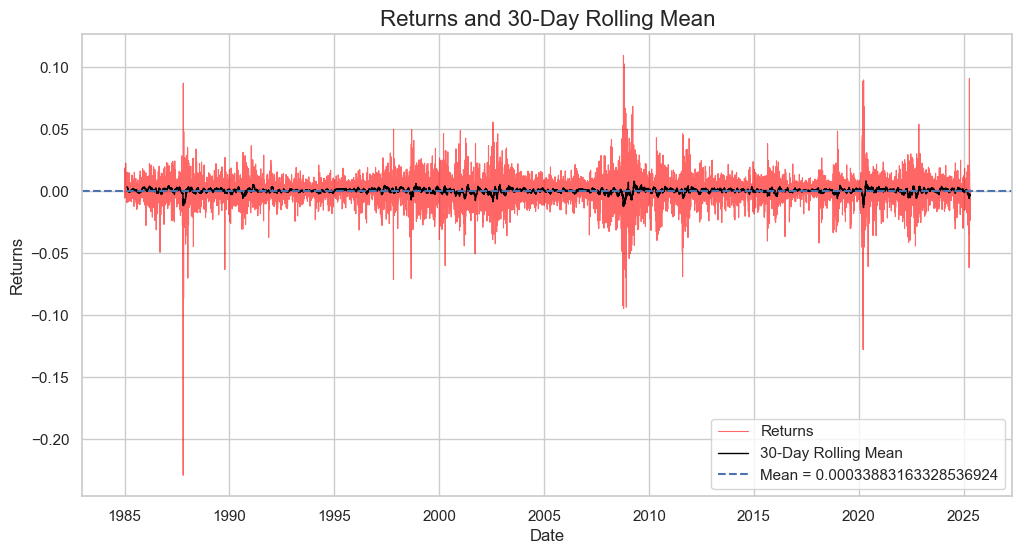

In [6]:

rolling_mean = df['Returns'].rolling(window=30).mean()

plt.figure(figsize=(12, 6))
sns.lineplot(x=df['Date'], y=df['Returns'], label='Returns', color='red', alpha=0.6, linewidth = 0.8)
sns.lineplot(x=df['Date'], y=rolling_mean, label='30-Day Rolling Mean', color='black', linewidth=1)
plt.axhline(y=df['Returns'].mean(), color='b', linestyle='--', label = "Mean = 0.00033883163328536924")


plt.title('Returns and 30-Day Rolling Mean', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Returns', fontsize=12)

plt.legend()

plt.show()

Mean return is small and positive.


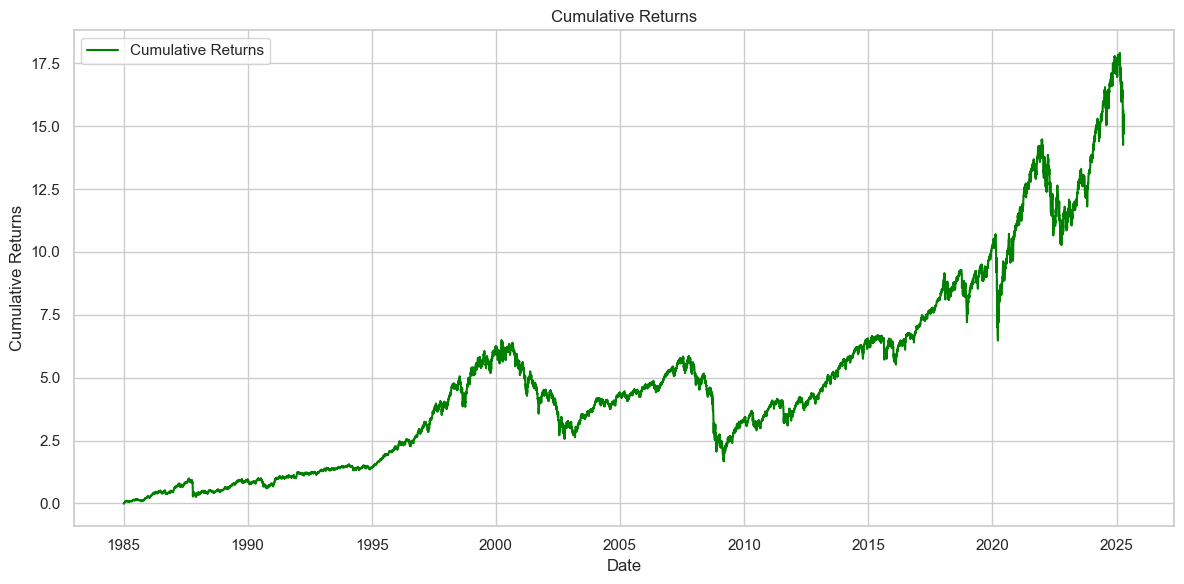

In [7]:

df['Cumulative_Returns'] = (1 + df['Returns']).cumprod() - 1


plt.figure(figsize=(12, 6))
sns.lineplot(x=df['Date'], y=df['Cumulative_Returns'], label='Cumulative Returns', color='green', linewidth=1.5)
            
plt.title('Cumulative Returns', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Returns', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

## ACF/PACF


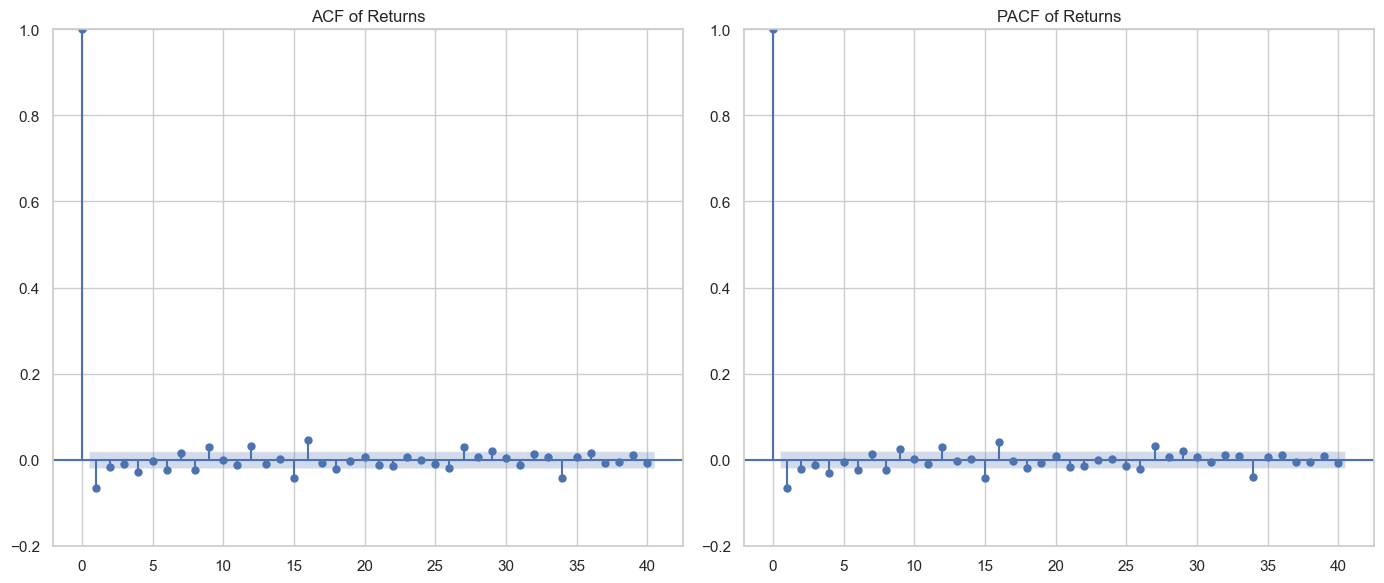

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ACF
plot_acf(df['Returns'].dropna(), lags=40, ax=axes[0])
axes[0].set_title('ACF of Returns', fontsize=12)
axes[0].set_ylim(-0.2, 1) 

# PACF
plot_pacf(df['Returns'].dropna(), lags=40, ax=axes[1], method='ywm')
axes[1].set_title('PACF of Returns', fontsize=12)
axes[1].set_ylim(-0.2, 1)

plt.tight_layout()
plt.show()

## Squared-Return ACF/PACF


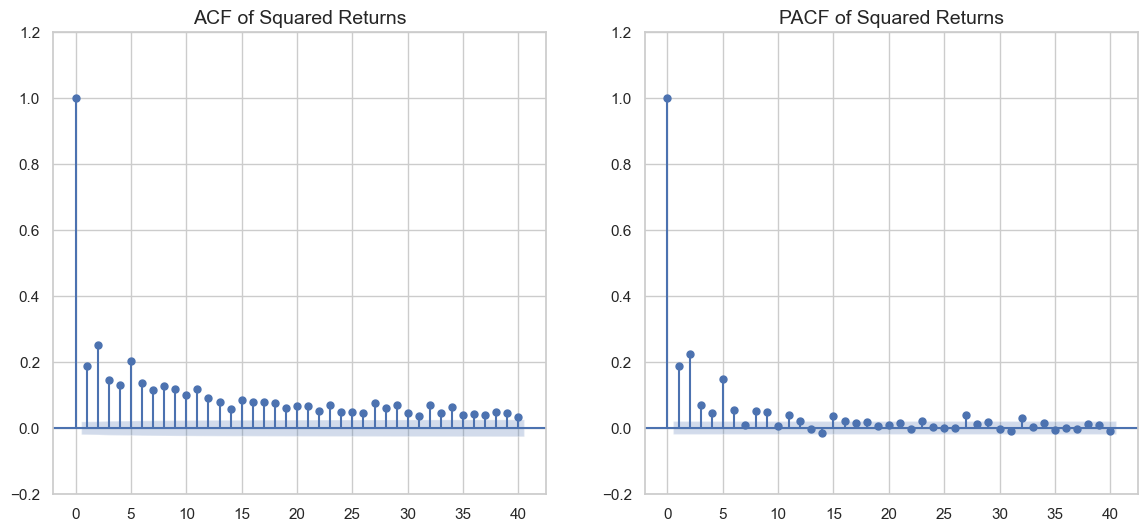

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Squared returns
squared_returns = df['Returns'].dropna() ** 2

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ACF 
plot_acf(squared_returns, lags=40, ax=axes[0])
axes[0].set_title('ACF of Squared Returns', fontsize=14)
axes[0].set_ylim(-0.2, 1.2)

# PACF
plot_pacf(squared_returns, lags=40, ax=axes[1], method='ywm')
axes[1].set_title('PACF of Squared Returns', fontsize=14)
axes[1].set_ylim(-0.2, 1.2)


plt.show()

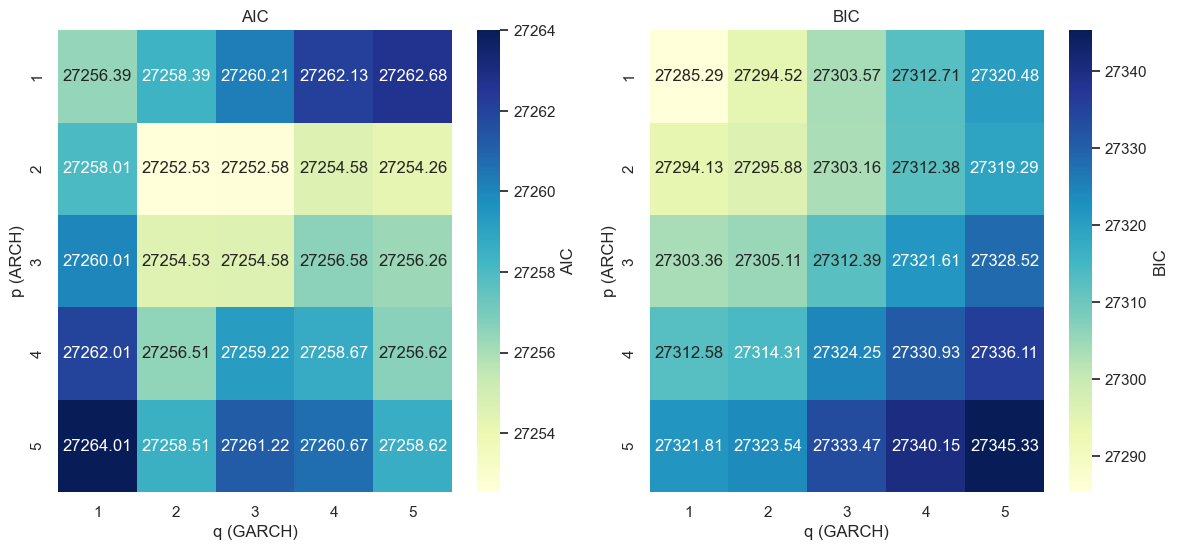

In [10]:

returns = df['Returns'].dropna()  

# scaling error: multiply by 100
returns = returns * 100 

# p (ARCH) and q (GARCH) : from the above plot only have to check for p<=5 and q<=5
p_values = range(1, 6) 
q_values = range(1, 6)  


aic_values = []
bic_values = []

# store aic bic values after fitting
for p in p_values:
    for q in q_values:
        try:
            model = arch_model(returns, vol='Garch', p=p, q=q)
            model_fit = model.fit(disp="off")
            
            
            aic_values.append(model_fit.aic)
            bic_values.append(model_fit.bic)
        except Exception as e:
            print(f"Error fitting model with p={p} and q={q}: {e}")
            aic_values.append(np.nan)
            bic_values.append(np.nan)


aic_matrix = np.array(aic_values).reshape(len(p_values), len(q_values))
bic_matrix = np.array(bic_values).reshape(len(p_values), len(q_values))


plt.figure(figsize=(14, 6))

# aic plot
plt.subplot(1, 2, 1)
sns.heatmap(aic_matrix, xticklabels=q_values, yticklabels=p_values, cmap="YlGnBu", annot=True, fmt=".2f", cbar_kws={'label': 'AIC'})
plt.title("AIC")
plt.xlabel('q (GARCH)')
plt.ylabel('p (ARCH)')

# bic plot
plt.subplot(1, 2, 2)
sns.heatmap(bic_matrix, xticklabels=q_values, yticklabels=p_values, cmap="YlGnBu", annot=True, fmt=".2f", cbar_kws={'label': 'BIC'})
plt.title("BIC")
plt.xlabel('q (GARCH)')
plt.ylabel('p (ARCH)')

plt.show()

## GARCH(1,1), Normal Innovations

Returns are scaled by 100 before fitting.


In [11]:

df['Returns'] = df['Returns']*100
model = arch_model(df['Returns'].dropna(), vol='Garch', p=1, q=1)
results = model.fit()

print(df.head())

print(results.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 2024784736992419.0
Iteration:      2,   Func. Count:     16,   Neg. LLF: 5778908492.659533
Iteration:      3,   Func. Count:     24,   Neg. LLF: 18709.773833018244
Iteration:      4,   Func. Count:     31,   Neg. LLF: 13831.312457583734
Iteration:      5,   Func. Count:     37,   Neg. LLF: 13642.431588438772
Iteration:      6,   Func. Count:     43,   Neg. LLF: 14082.88290001673
Iteration:      7,   Func. Count:     49,   Neg. LLF: 13625.1327643917
Iteration:      8,   Func. Count:     55,   Neg. LLF: 13624.196129510316
Iteration:      9,   Func. Count:     60,   Neg. LLF: 13624.195441381094
Iteration:     10,   Func. Count:     65,   Neg. LLF: 13624.195439555202
Iteration:     11,   Func. Count:     69,   Neg. LLF: 13624.195439554784
Optimization terminated successfully    (Exit mode 0)
            Current function value: 13624.195439555202
            Iterations: 11
            Function evaluations: 69
            Gradient evaluat

## Residual Normality


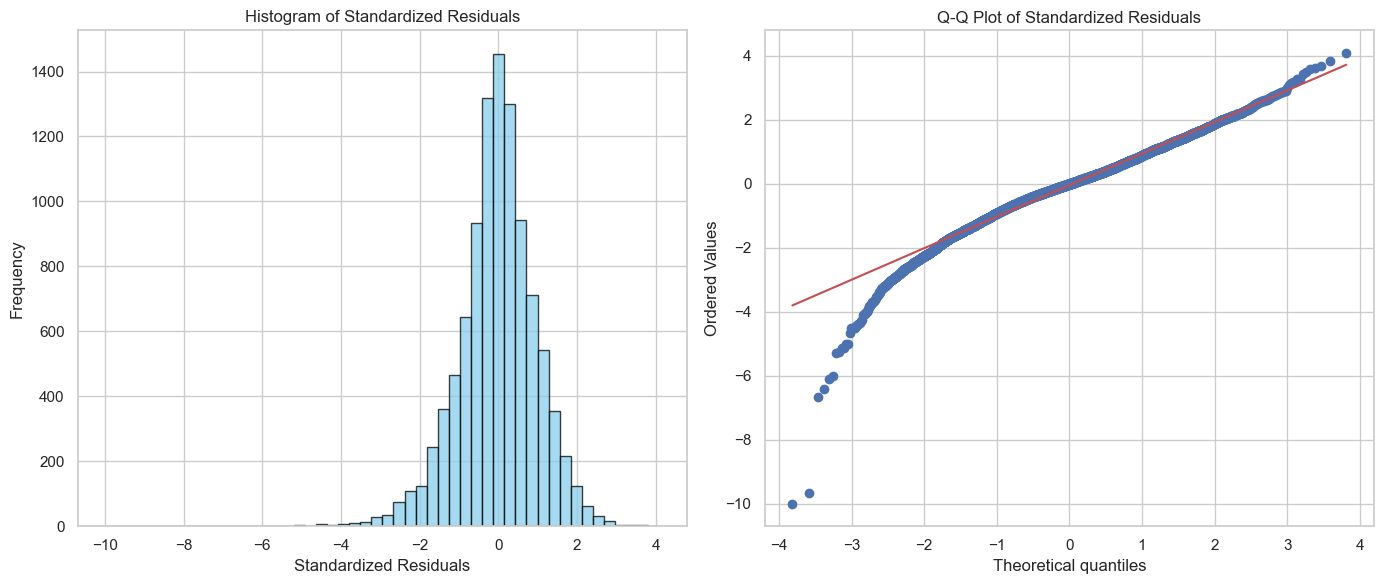

In [12]:
# Reuse the GARCH(1,1) fit from above (no need to refit) -- get residuals
# and conditional volatility to check the normality assumption.
residuals = results.resid
conditional_volatility = results.conditional_volatility

# Standardize the residuals
standardized_residuals = residuals / conditional_volatility

# Add standardized residuals to the dataframe
df['Standardized Residuals'] = standardized_residuals

# Create the plot with two subplots: histogram and Q-Q plot
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Plot histogram
axs[0].hist(df['Standardized Residuals'].dropna(), bins=50, alpha=0.75, color='skyblue', edgecolor='black')
axs[0].set_title('Histogram of Standardized Residuals')
axs[0].set_xlabel('Standardized Residuals')
axs[0].set_ylabel('Frequency')

# Plot Q-Q plot
stats.probplot(df['Standardized Residuals'].dropna(), dist="norm", plot=axs[1])
axs[1].set_title('Q-Q Plot of Standardized Residuals')

plt.tight_layout()
plt.show()


## GARCH(1,1), t Innovations


In [13]:
# t-distributed errors
model_t = arch_model(df['Returns'].dropna(), vol='Garch', p=1, q=1, dist='t')
results_t = model_t.fit()


print(results_t.summary())


Iteration:      1,   Func. Count:      7,   Neg. LLF: 584111.8087911017
Iteration:      2,   Func. Count:     19,   Neg. LLF: 141822.84886361088
Iteration:      3,   Func. Count:     28,   Neg. LLF: 80429.78277783602
Iteration:      4,   Func. Count:     36,   Neg. LLF: 13348.489456995427
Iteration:      5,   Func. Count:     43,   Neg. LLF: 22160.065344612587
Iteration:      6,   Func. Count:     50,   Neg. LLF: 13345.227272590517
Iteration:      7,   Func. Count:     57,   Neg. LLF: 13292.567667685636
Iteration:      8,   Func. Count:     64,   Neg. LLF: 13873.233554016213
Iteration:      9,   Func. Count:     71,   Neg. LLF: 13292.316664205735
Iteration:     10,   Func. Count:     78,   Neg. LLF: 13343.545239717048
Iteration:     11,   Func. Count:     85,   Neg. LLF: 13289.318560675561
Iteration:     12,   Func. Count:     91,   Neg. LLF: 13289.313881376402
Iteration:     13,   Func. Count:     97,   Neg. LLF: 13289.313873605148
Iteration:     14,   Func. Count:    102,   Neg. LLF:

In [14]:
alpha1 = results_t.params['alpha[1]']
beta1 = results_t.params['beta[1]']
persistence = alpha1 + beta1

# Use the model's own parameter covariance matrix (results_t.param_cov) to get
# the standard error of alpha1+beta1 correctly, accounting for the
# correlation between alpha1 and beta1, rather than just summing their
# individual (marginal) standard errors.
cov = results_t.param_cov
var_persistence = (cov.loc['alpha[1]', 'alpha[1]'] + cov.loc['beta[1]', 'beta[1]']
                    + 2 * cov.loc['alpha[1]', 'beta[1]'])
se_persistence = np.sqrt(var_persistence)
ci_low, ci_high = persistence - 1.96 * se_persistence, persistence + 1.96 * se_persistence

half_life = np.log(0.5) / np.log(persistence)

print(f"alpha1 + beta1 = {persistence:.4f} (SE = {se_persistence:.4f}, "
      f"95% CI [{ci_low:.4f}, {ci_high:.4f}])")
print(f"Volatility shock half-life: {half_life:.1f} trading days")


alpha1 + beta1 = 0.9944 (SE = 0.0034, 95% CI [0.9878, 1.0010])
Volatility shock half-life: 124.3 trading days


## Volatility Persistence

The fitted t-GARCH model is highly persistent: `alpha1 + beta1 = 0.9944`.


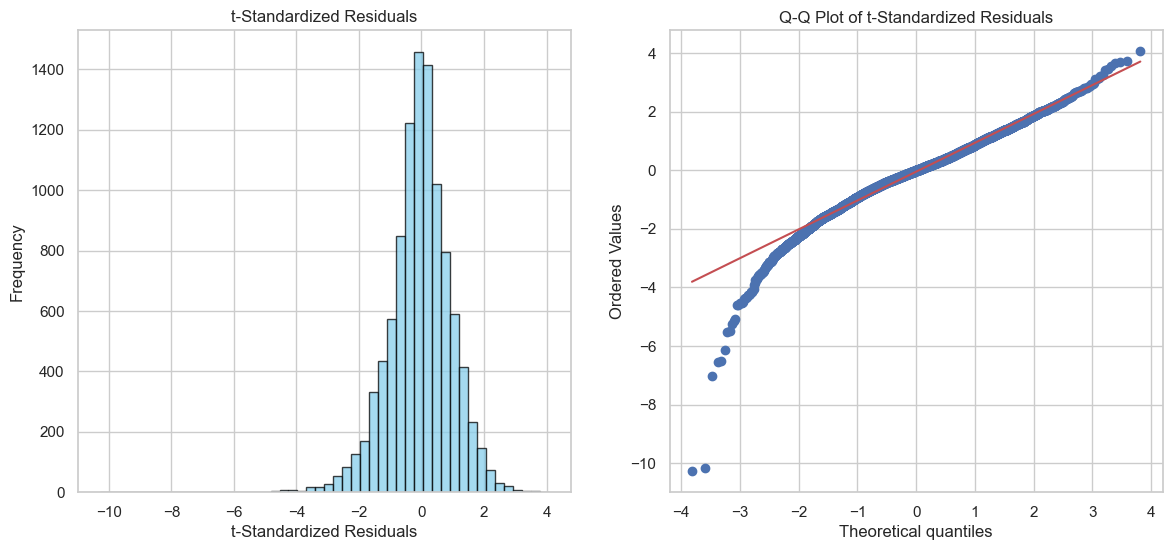

In [15]:

residuals_t = results_t.resid
conditional_volatility_t = results_t.conditional_volatility


standardized_residuals_t = residuals_t / conditional_volatility_t
################ standardized residuals to the dataframe


df['t Standardized Residuals'] = standardized_residuals_t  # removed trailing space


fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# residual hist
axs[0].hist(df['t Standardized Residuals'].dropna(), bins=50, alpha=0.75, color='skyblue', edgecolor='black')
axs[0].set_title('t-Standardized Residuals')
axs[0].set_xlabel('t-Standardized Residuals')
axs[0].set_ylabel('Frequency')

# q-q
stats.probplot(df['t Standardized Residuals'].dropna(), dist="norm", plot=axs[1])
axs[1].set_title('Q-Q Plot of t-Standardized Residuals')

plt.show()

## Standardized Residuals Over Time


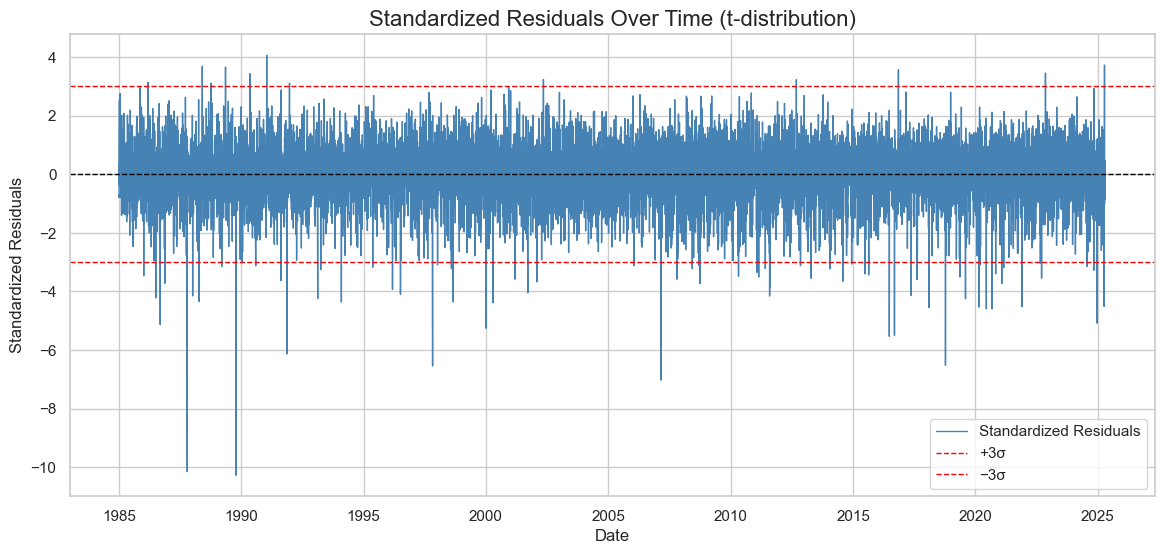

In [16]:
# plot
plt.figure(figsize=(14, 6))
sns.lineplot(x=df['Date'], y = standardized_residuals_t, label='Standardized Residuals',  color='steelblue', linewidth=1)


plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axhline(3, color='red', linestyle='--', linewidth=1, label='+3σ')
plt.axhline(-3, color='red', linestyle='--', linewidth=1, label='−3σ')

# Labels and legend
plt.title('Standardized Residuals Over Time (t-distribution)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Standardized Residuals')
plt.legend()


plt.show()

In [17]:
# ---------------------------------------------------------------------------
# Hand-off to 02_evt_threshold_analysis.ipynb.
#
# standardized_residuals.csv: per-day series -- residuals, conditional
# volatility, and the (constant) conditional mean -- so the EVT notebook can
# both fit the GPD tail AND convert its standardized-residual VaR figures
# back to actual return-scale VaR, without refitting GARCH.
#
# garch_params.csv: one-row file with the one-step-ahead volatility
# forecast and the fitted GARCH-t parameters needed for the t-distribution
# consistency check and the persistence discussion above.
# ---------------------------------------------------------------------------

mu_hat = results_t.params['mu'] / 100          # back to log-return scale
nu_hat = results_t.params['nu']

handoff = df[['Date', 'Close', 't Standardized Residuals']].copy()
handoff['Conditional Volatility'] = conditional_volatility_t / 100  # log-return scale
handoff['Mu'] = mu_hat
handoff = handoff.dropna()
handoff.to_csv('standardized_residuals.csv', index=False)
print(f"Saved {len(handoff)} rows to standardized_residuals.csv")

sigma_forecast = np.sqrt(results_t.forecast(horizon=1).variance.iloc[-1, 0]) / 100
sigma_avg = handoff['Conditional Volatility'].mean()

params = pd.DataFrame([{
    'Mu': mu_hat,
    'Sigma_Hat_Next': sigma_forecast,        # one-step-ahead forecast, log-return scale
    'Sigma_Hat_Avg': sigma_avg,              # mean realized in-sample volatility, log-return scale
    'Nu': nu_hat,
    'Alpha1': alpha1,
    'Beta1': beta1,
    'Persistence': persistence,
}])
params.to_csv('garch_params.csv', index=False)
print(f"Saved garch_params.csv:")
params


Saved 10153 rows to standardized_residuals.csv
Saved garch_params.csv:


,Mu,Sigma_Hat_Next,Sigma_Hat_Avg,Nu,Alpha1,Beta1,Persistence
0,0.000764,0.028456,0.010205,5.763347,0.094384,0.900053,0.994438


In [18]:
# predict price 2 days later
np.random.seed(2312)
forecast = results_t.forecast(horizon=2)


var_tomorrow = forecast.variance.iloc[-1, 0]
var_day_after = forecast.variance.iloc[-1, 1]

# standard deviation
vol_tomorrow = np.sqrt(var_tomorrow) / 100
vol_day_after = np.sqrt(var_day_after) / 100 #multiplied by 100 earlier


mu = results_t.params['mu'] / 100 # t-parameters residuals
nu = results_t.params['nu']


shock_tomorrow = np.random.standard_t(nu) # shocks
shock_day_after = np.random.standard_t(nu)


log_ret_tomorrow = mu + vol_tomorrow * shock_tomorrow #log returns
log_ret_day_after = mu + vol_day_after * shock_day_after


current_price = df["Close"].iloc[-1]


price_tomorrow = current_price * np.exp(log_ret_tomorrow)/10 # forecast 
price_day_after = price_tomorrow * np.exp(log_ret_day_after)


print(f"Closing Price on 21 April: {current_price/10} ")
print(f"Forecasted price 22 April: ${price_tomorrow:.2f}")
print(f"Actual Closing Price on 22 April: $527")
print(f"Forecasted price 23 April: ${price_day_after:.2f}")

Closing Price on 21 April: 515.82001953125 
Forecasted price 22 April: $530.68
Actual Closing Price on 22 April: $527
Forecasted price 23 April: $546.48
